In [ ]:
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from google.colab import drive
from skimage.io import imread, imshow
from skimage.transform import resize
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (precision_recall_curve, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay)
import pickle
import cv2


import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Conv2D, Conv2DTranspose, Concatenate, BatchNormalization, Activation, Dropout, MaxPooling2D, UpSampling2D, multiply, add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer

In [ ]:

def Weighted_Cross_Entropy(beta):
    def convert_to_logits(y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        return tf.math.log(y_pred / (1 - y_pred))

    def loss(y_true, y_pred):
        y_pred = convert_to_logits(y_pred)
        loss = tf.nn.weighted_cross_entropy_with_logits(logits=y_pred, labels=y_true, pos_weight=beta)
        return tf.reduce_mean(loss)

    return loss

In [ ]:
# Access Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

modelo1 = load_model('/content/model_01.h5', custom_objects={'loss': Weighted_Cross_Entropy(10.0)}, safe_mode=False)
modelo2 = load_model('/content/model_03.h5', custom_objects={'loss': Weighted_Cross_Entropy(10.0)}, safe_mode=False)
modelo3 = load_model('/content/model_02.h5', custom_objects={'loss': Weighted_Cross_Entropy(10.0)}, safe_mode=False)
modelo4 = load_model('/content/model_04.h5', custom_objects={'loss': Weighted_Cross_Entropy(10.0)}, safe_mode=False)

## COMPARACION VALIDACION

In [ ]:
# Image Paths
img_truev= [
    '/content/drive/MyDrive/01Tesis/DatosSG/val/images/v30.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/images/v7.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/images/v6.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/images/v36.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/images/v5.png',]

mask_truev = [
    '/content/drive/MyDrive/01Tesis/DatosSG/val/masks/v30.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/masks/v7.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/masks/v6.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/masks/v36.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/val/masks/v5.png',]

listas_imgs = [img_truev, mask_truev]

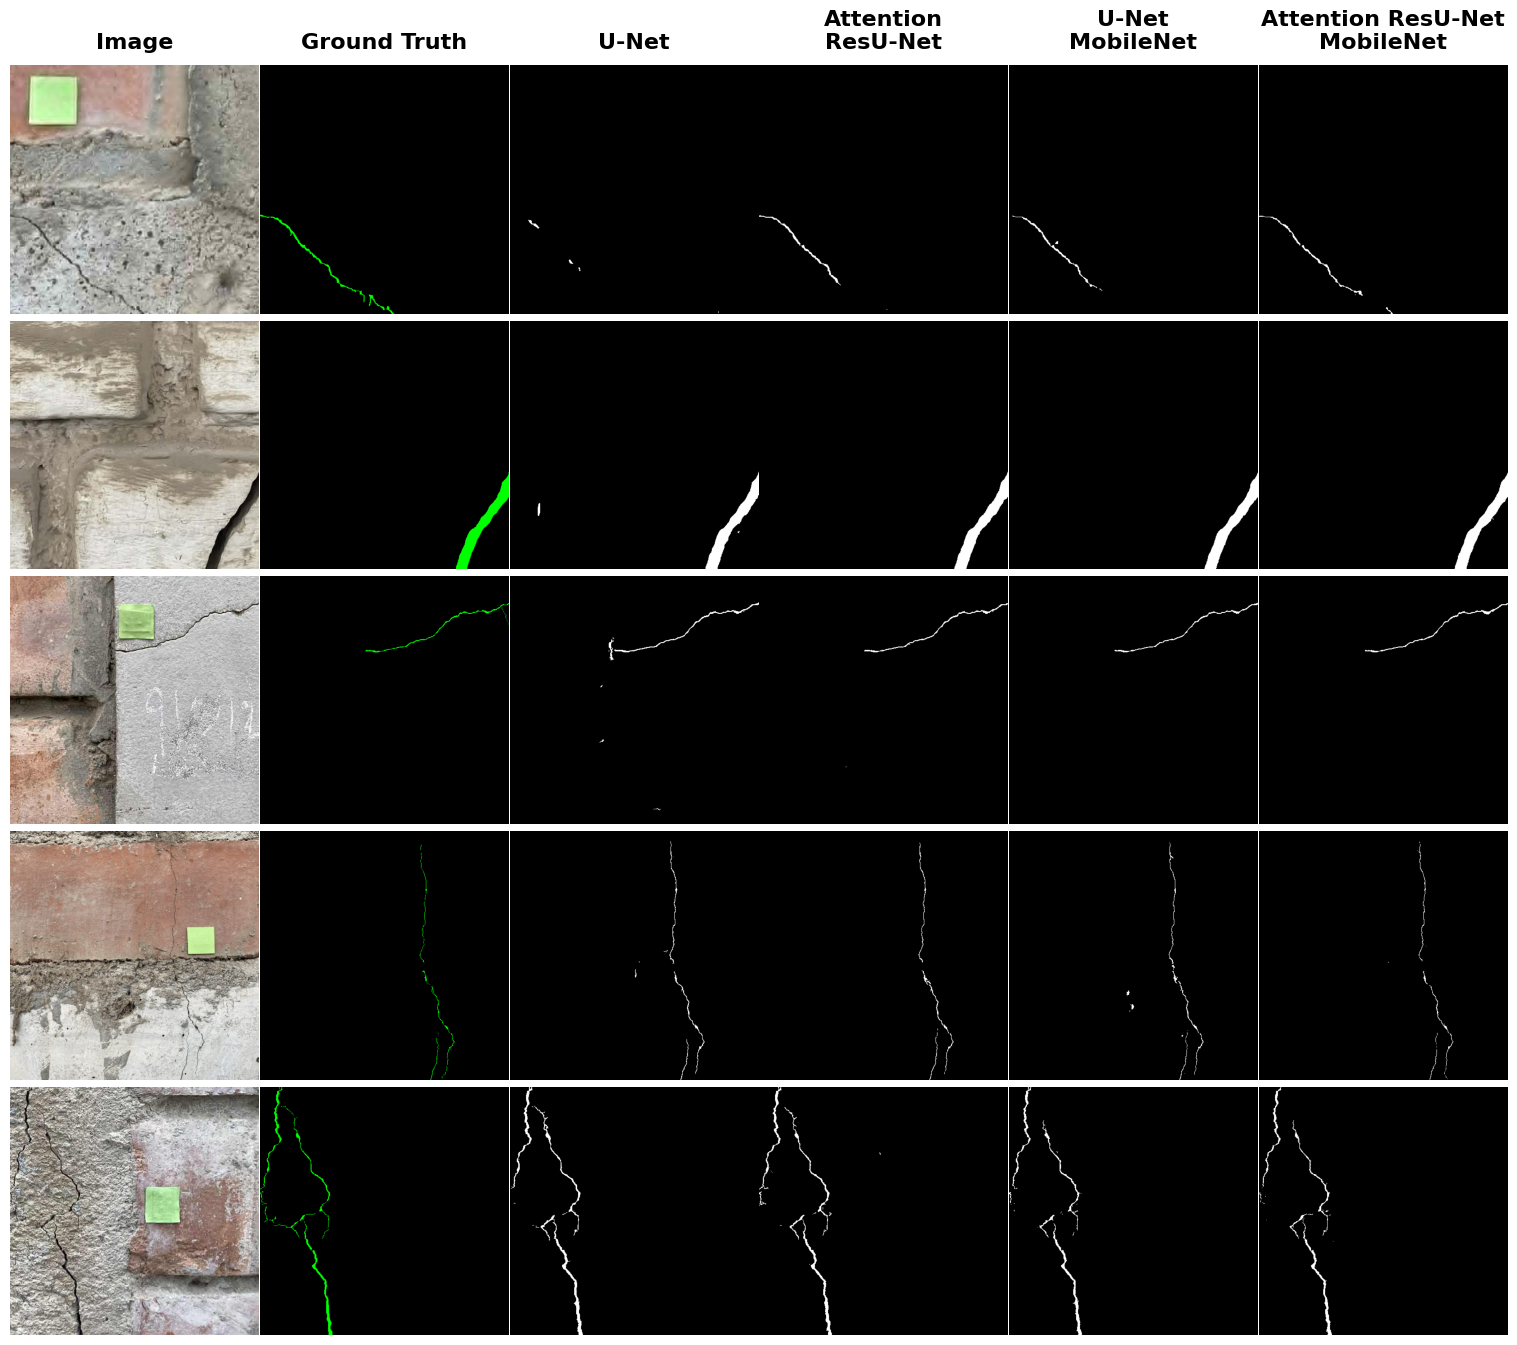

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 512

modelos = [
    ("U-Net", modelo1),
    ("Attention\nResU-Net", modelo2),
    ("U-Net\nMobileNet", modelo3),
    ("Attention ResU-Net\nMobileNet", modelo4),
]

fig, axes = plt.subplots(len(img_truev), 6, figsize=(15, 13.4))

titulos = [
    "Image",
    "Ground Truth",
    modelos[0][0],
    modelos[1][0],
    modelos[2][0],
    modelos[3][0]
]

# Títulos
for j, t in enumerate(titulos):
    axes[0, j].set_title(t, fontsize=16, fontweight='bold', pad=12)

for i in range(len(img_truev)):

    # Imagen original
    img = cv2.imread(img_truev[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ground truth
    mask = cv2.imread(mask_truev[i], 0)

    # Input modelo
    inp = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    inp = inp.astype(np.float32)
    inp = np.expand_dims(inp, axis=0)

    # ---------------- IMAGE ----------------
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")

    # ---------------- GT ----------------
    gt_color = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    gt_color[mask > 0] = [0, 255, 0]
    axes[i, 1].imshow(gt_color)
    axes[i, 1].axis("off")

    # ---------------- PREDICCIONES ----------------
    for k, (_, modelo) in enumerate(modelos):

        pred = modelo.predict(inp, verbose=0)[0]

        if pred.ndim == 3:
            pred = pred[:, :, 0]

        pred = (pred > 0.5).astype(np.uint8)

        pred_color = np.zeros((pred.shape[0], pred.shape[1], 3), dtype=np.uint8)
        pred_color[pred > 0] = [255, 255, 255]

        axes[i, k + 2].imshow(pred_color)
        axes[i, k + 2].axis("off")

# 🔥 AJUSTE FUERTE DE ESPACIADO (CLAVE)
fig.subplots_adjust(
    wspace=0.01,
    hspace=0.01
)

plt.tight_layout(pad=0.1)


# ===== Guardar imagen =====
plt.savefig(
    "comparacion_modelos.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)


plt.show()

In [ ]:
from google.colab import files
files.download("comparacion_modelos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## COMPARACION TESTEO

In [ ]:
# Image Paths
img_true= [
    '/content/drive/MyDrive/01Tesis/DatosSG/test/images/t4.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/images/t16.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/images/t5.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/images/t2.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/images/t19.png',]

mask_true = [
    '/content/drive/MyDrive/01Tesis/DatosSG/test/masks/t4.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/masks/t16.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/masks/t5.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/masks/t2.png',
    '/content/drive/MyDrive/01Tesis/DatosSG/test/masks/t19.png',]

listas_imgs = [img_true, mask_true]

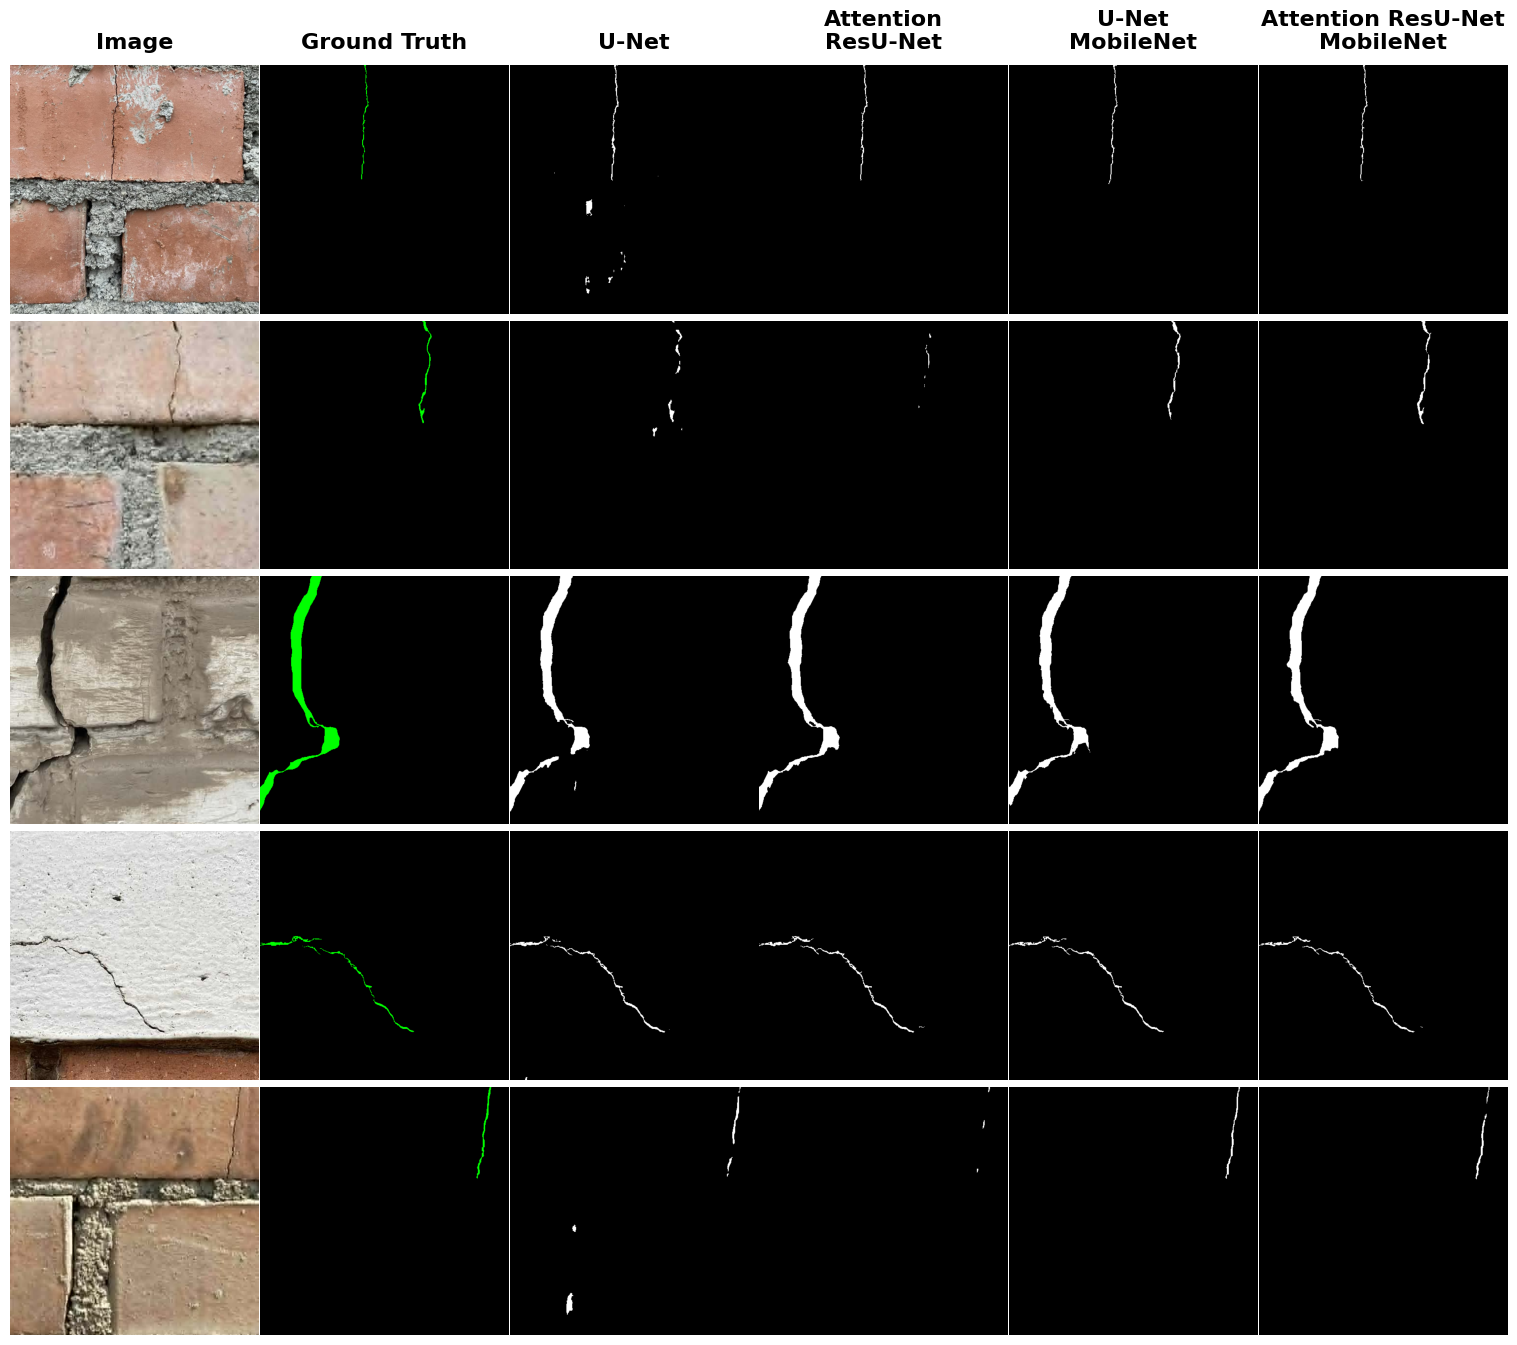

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 512

modelos = [
    ("U-Net", modelo1),
    ("Attention\nResU-Net", modelo2),
    ("U-Net\nMobileNet", modelo3),
    ("Attention ResU-Net\nMobileNet", modelo4),
]

fig, axes = plt.subplots(len(img_true), 6, figsize=(15, 13.4))

titulos = [
    "Image",
    "Ground Truth",
    modelos[0][0],
    modelos[1][0],
    modelos[2][0],
    modelos[3][0]
]

# Títulos
for j, t in enumerate(titulos):
    axes[0, j].set_title(t, fontsize=16, fontweight='bold', pad=12)

for i in range(len(img_true)):

    # Imagen original
    img = cv2.imread(img_true[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ground truth
    mask = cv2.imread(mask_true[i], 0)

    # Input modelo
    inp = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    inp = inp.astype(np.float32)
    inp = np.expand_dims(inp, axis=0)

    # ---------------- IMAGE ----------------
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")

    # ---------------- GT ----------------
    gt_color = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    gt_color[mask > 0] = [0, 255, 0]
    axes[i, 1].imshow(gt_color)
    axes[i, 1].axis("off")

    # ---------------- PREDICCIONES ----------------
    for k, (_, modelo) in enumerate(modelos):

        pred = modelo.predict(inp, verbose=0)[0]

        if pred.ndim == 3:
            pred = pred[:, :, 0]

        pred = (pred > 0.5).astype(np.uint8)

        pred_color = np.zeros((pred.shape[0], pred.shape[1], 3), dtype=np.uint8)
        pred_color[pred > 0] = [255, 255, 255]

        axes[i, k + 2].imshow(pred_color)
        axes[i, k + 2].axis("off")

# 🔥 AJUSTE FUERTE DE ESPACIADO (CLAVE)
fig.subplots_adjust(
    wspace=0.01,
    hspace=0.01
)

plt.tight_layout(pad=0.1)


# ===== Guardar imagen =====
plt.savefig(
    "comparacion_modelos.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)


plt.show()

In [ ]:
from google.colab import files
files.download("comparacion_modelos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>